# COM4509/6509 Assignment 2025/6

Hello, this is the programming assignment for *Machine Learning and Adaptive Intelligence*. This is worth 50% of the module grade, the remaining 50% will be assessed via the formal exam.

**Deadline: 12th December 2025, 23:59**

Please submit well before the deadline as there may be delays in the submission. Submission will be via Blackboard.

There are 2 parts to this assignment, covering different portions of the course. Both parts are worth 50 marks to give a combined total of 100 marks. Both contain a set of questions which will ask you to implement various machine learning algorithms that are covered throughout the course. You will receive marks for the correctness of your implementations, text based responses to certain questions and the quality of your code. Each question indicates how many marks are available.

### Use of unfair means and Generative AI

For this assignment **you must not use code/text produced by generative AI, that is created using a prompt**. The 'autocomplete' feature in colab can still be used.

This is an individual assignment, while you may discuss this with your classmates, **please make sure you submit your own code**. You are allowed to use code from the labs as a basis of your submission.

The university's policy on the use of GenAI is on [this page](https://www.sheffield.ac.uk/study-skills/digital/generative-ai/assessment).

"Any form of unfair means is treated as a serious academic offence and action may be taken under the Discipline Regulations." (from the students Handbook).

### Assessment Criteria

- You will be assessed on:
  - Correctness of your implementations
  - Clarity and organization of your code with appropriately detailed comments
  - Quality of your explanations and justifications
  
Further details of the marking criteria will be provided on the VLE.

### Assignment help

If you are stuck and unsure what you need to do then please ask either in the lectures, labs or on the discussion board. There is a limit to what help we can provide but where possible we will give general guidance with how to proceed.

We are happy for you to discuss the assignment with other students but your code and test answers **must** be your own.

### What to submit

- You need to submit a **pdf** of your notebook *and* the **notebook**. Please name them:

```
assignment_[username].ipynb
assignment_[username].pdf
```
replacing `[username]` with your username, e.g. `abc18de`.

- **Please execute the cells before your submission**, so we can see the results in the pdf. The best way to get a pdf is using Jupyter Notebook locally but if you are using Google Colab and are unable to download it to use Jupyter then you can use the Google Colab *file $\rightarrow$ print* to get a pdf copy.
- **Please do not upload** the data files used in this Notebook. We just want the python notebook *and the pdf*.

### Late submissions

We follow the department's guidelines about late submissions, Undergraduate [handbook link](https://sites.google.com/sheffield.ac.uk/comughandbook/your-study/assessment/late-submission). PGT [handbook link](https://sites.google.com/sheffield.ac.uk/compgtstudenthandbook/home/your-study/assessment/late-submission).


# Part 1: Linear Regression, Likelihood Functions and Gradient Descent

This is the _first_ of the two parts, accounting for 50 marks of the overall coursework mark.

## Overview

This part of the assignment will cover Linear Regression(week 4), gradient descent, and, from week 1 and 2: broader understanding of ML, interpretation of datasets and model evaluation.

### Allowed libraries

For this part, the libraries you will need are already imported in the code.

### Assessment Distribution

- The marks for this part are distributed as follows:
  - **1.1**: 4 marks
  - **1.2**: 20 marks
  - **1.3**: 10 marks
  - **1.4**: 4 marks
  - **1.5**: 12 marks

[21 marks are for interpretation (written answers), and 29 marks are for coding-based answers].



## The Challenge

The Sheffield Machine Learning research group is developing approaches to track bees flying over the landscape.

In this example we track a bee flying from a flower to a nest, and across this flight measure the following at some time points:

- the direction the bee is facing
- the height of the bee above sea-level
- the start and end locations of its flight (i.e. the location of the flower and the nest)

We have used expensive harmonic radar to ground-truth 36 flight paths. This data is stored in `all_datasets`. For the code below we will only use the first flight path:

`dataset = all_datasets[0]`.

(Note: This dataset is really synthetic!)

# 1.1 Generating a path

We will model the flight path of a bee over a 90 second interval. We will model the x-coordinate and the y-coordinate with two independent linear regressors, each with a Gaussian basis function.

First, write a function, which takes a vector of times and a vector of 8 weights, and which produces predictions at those times using a Gaussian basis, with a **width of 20s**, spaced evenly, centred on these times: -4, 10, 24, 38, 52, 66, 80, 94. For example you could use: `np.arange(-4,96,14)`
Have a look at the [definition of a Gaussian function](https://en.wikipedia.org/wiki/Gaussian_function) (don't forget the 1/2 inside the exponent!).
This function is generating the predicted x or y values at different times.

Note: We will later be using [JAX](https://docs.jax.dev/en/latest/index.html) to do autodiff on our expressions (for use with gradient descent) so we will be using the jax implementation of numpy. This means there are some differences that you might come across in the numpy library.

Use this exact `def` set of arguments etc (so we can test and run your code).


### 1.1.1. Implement `get_pred`
[2 marks]

In [3]:
##Note: We're going to use JAX for doing autodiff for the first part of the coursework,
##so we'll use jax's numpy:
import jax.numpy as np
import numpy as standard_np
import matplotlib.pyplot as plt

def get_pred(T,w):
  """
  Calculates predicted values along one coordinate, using a weighted sum of Gaussian basis functions.

  Args:
    T: A 1d array of time points.
    w: A 1d array of 8 weights for the 8 basis functions.

  Returns:
    An array of predicted locations along one coordinate axis (of the same length as T).
  """
  centres = np.arange(-4, 96, 14)
  width = 20.0

  preds_list = []

  for ti in T:

      gauss_values = []
      for c in centres:
          diff = ti - c
          g = np.exp(-(diff * diff) / (2 * width * width))
          gauss_values.append(g)

      total = 0.0
      for j in range(8):
          total += gauss_values[j] * w[j]
          
      preds_list.append(total)

  return np.array(preds_list)

We next want to produce predictions at both x and y coordinates. For this we need 16 weight values in our `w` vector (8 for the x coordinate, and 8 for the y coordinate).

Implement the following `get_path` method. This takes a vector of times for which we want the path coordinates, and a concantenated `w` (containing 16 values).

When implementing, you will want to call the `get_pred` method, with the first 8 or last 8 of the elements in `w`. The `get_path` method should then return a 2d array (shape: len(T) x 3) with columns containing the **time, x and y**. For example:
```
      Time     X    Y
         0  12.3 45.1
        10   6.3  5.4
        20   4.1  8.3
         :    :    :
```

### 1.1.2 Implement `get_path`

[2 marks]

In [4]:
def get_path(T, w):
    """
    Calculates both coordinates of the path of the bee, given
    the 16 weights in the w vector.

    Args:
      T: A 1d array of time points.
      w: A 1d array of 16 weights (8 for the x-axis, 8 for the y-axis).

    Returns:
      An 2d array (shape: len(T) x 3) of time, x and y vectors.
    """

    wx = w[0:8]
    wy = w[8:16]

    x = get_pred(T, wx)
    y = get_pred(T, wy)

    return np.stack([T, x, y], axis=1)

## Tests

To check you've coded these methods correctly, here's some unit tests:

Passed all tests.


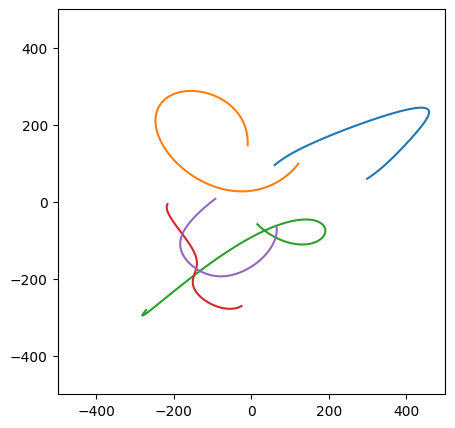

In [5]:
import math

#Test get_pred
preds = get_pred(np.array([-100,50,51]),np.arange(8))
for p,a in zip(preds,np.array([0, 13.7, 13.9])):
  assert math.isclose(p,a,rel_tol=0.05,abs_tol=0.01), "Output doesn't match expected values"

#Test get_path
path = get_path(np.array([-100,50,51]),np.arange(16))
for px,py,ax,ay in zip(path[:,1],path[:,2],np.array([0, 13.6, 13.9]),np.array([0, 42.2, 42.4])):
  assert math.isclose(px,ax,rel_tol=0.05,abs_tol=0.01), "Output doesn't match expected values"
  assert math.isclose(py,ay,rel_tol=0.05,abs_tol=0.01), "Output doesn't match expected values"

print("Passed all tests.")

#Print 5 random sample paths
standard_np.random.seed(0)
plt.figure(figsize=[5,5])
plt.axis([-500,500,-500,500])
for example in range(5):
  w = 100*standard_np.random.randn(16)
  path = get_path(np.linspace(0,90,100),w)
  plt.plot(path[:,1],path[:,2])


## Download the dataset

In [6]:
import urllib
urllib.request.urlretrieve('https://drive.usercontent.google.com/download?id=1TdUyUnNDoPfJl-Cyx1fvUhYlXyPJgGle&export=download','heights.npy')
urllib.request.urlretrieve('https://drive.usercontent.google.com/download?id=1-Eqcq4pjiBStSbLgN6CEsVZpZ98l00Na&export=download','datasets.npy')
all_datasets = np.load('datasets.npy',allow_pickle=True)
sample_times = all_datasets[0]['actual_path'][:,0] #this is the same for all datasets
heights = np.load('heights.npy')

**all_datasets** contains 36 tracked paths of bees. Each is a dictionary, and consists of:
* **['actual_path']** - the ground truth path the bee took, stored as a $10 \times 3$ array, with columns: *time, x, y*.
*  **['height_data']** - the height above sea level of the bee at every time point in *sample_times*
* **['direction_data']** - Three unit vectors representing the direction a bee was facing at three times across the path, stored an $3 \times 3$ array, with columns: *time, vector_x, vector_y*.
* **['position_data']** - the start and end position of the bees flight, stored as a $2 \times 3$ array, with columns: *time, x, y*.


## Helpful functions you might use

Here are a couple of functions that you might find useful.

In [7]:
def get_height_at_location(p):
  """Return the interpolated value at floating point locations in p.
  Handles edges, and uses jax to allow for gradient calculations.
  Used to get the height of the terrain (above sea level) at location p.
  Args:
    p: A 1d 3-element array describing the time,x,y coordinate.
        (only the x and y components are used)

  Returns:
    a scalar value of the height at that location.
  """
  p = (p + 500)/4
  pos = np.min(np.c_[np.max(np.c_[p[1:3],[0,0]],1),[248,248]],1).astype(int)
  ratiox = p[1]%1
  ratioy = p[2]%1
  interp_val = (heights[pos[0],pos[1]]*(1-ratiox) + heights[pos[0]+1,pos[1]]*ratiox)*(1-ratioy) + (heights[pos[0],pos[1]+1]*(1-ratiox) + heights[pos[0]+1,pos[1]+1]*ratiox)*ratioy
  return interp_val

def plot_path(ws,dataset):
  """
  Plots the path associated with weights in 'ws'.
  Also plots the actual path and the terrain map in 'heights'.

  Args:
    ws: Either a 1d array of 16 weights (8 for the x-axis, 8 for the y-axis).
       or a 2d array, each row a single w.
    dataset: a dictionary of observation data about a single bee's flight.
  """
  if len(ws.shape)==1: ws = ws[None,:]
  paths = []
  for w in ws:
    paths.append(get_path(sample_times,w))
  plt.figure(figsize=[6,6])
  plt.axis([-500,500,-500,500])
  plt.contour(np.linspace(-500,500,250),np.linspace(-500,500,250),heights.T)
  for path in paths:
    plt.plot(path[:,1],path[:,2],'k-',alpha=1/standard_np.sqrt(len(paths)))
    plt.plot(path[-1,1],path[-1,2],'k-o')
    plt.plot(path[0,1],path[0,2],'k-+')
  ap = dataset['actual_path']
  dd = dataset['direction_data']
  plt.plot(ap[:,1],ap[:,2],'b-')
  plt.plot(ap[-1,1],ap[-1,2],'bo')
  plt.plot(ap[0,1],ap[0,2],'b+')
  for d in dd:
    actPos = ap[ap[:,0]==d[0],:][0]
    plt.plot([actPos[1],actPos[1]+d[1]*100],[actPos[2],actPos[2]+d[2]*100],'b-',lw=3)
    plt.plot(actPos[1],actPos[2],'bo',markersize=6)
    if len(paths)==1:
      for path in paths:
        predPos = path[path[:,0]==d[0],:][0]
        plt.plot([predPos[1],predPos[1]+d[1]*100],[predPos[2],predPos[2]+d[2]*100],'k-',lw=3)
        plt.plot(predPos[1],predPos[2],'ko',markersize=6)


# 1.2 Write log likelihood functions for the three types of data

To find the flight path of the bee, we will want to determine how good a given choice of `w` is (and so be able to [auto]differentiate it and optimise wrt a cost function).

This cost function is the negative log probability. To compute this we need to find the log likelihood of the three types of observations (given a choice of `w`).

We will do this by first, for a given `w`, compute the path (using the `get_path` method above). We then will use that as our prediction and ask how well does this explain the observations (provided in the `dataset` dictionary).



## 1.2.1 Height

We have observations of the bee's height above sea level using a barometric pressure sensor on the tag. We can combine this with the region's very steep terrain to help us infer the bee's location.

You need to write a function that computes the log probability of the height observations (and the terrain height) GIVEN a predicted path (in `path`).

You'll want to use the `get_height_at_location` function to get the height of the ground at each location along the path. We assumed when generating this dataset that bees fly between 0m and 2m above the ground at all times - so you can use that when devising an appropriate likelihood. A possible choice would be a simple normal distribution.

To help, the colab already has the normal distribution imported: `from jax.scipy.stats import norm`. You can use this to compute the log probability of a normal distribution with, for example calling `norm.logpdf(3.1,5,10)` returns the log pdf (-3.239573) at value = 3.1, for a univariate normal with a mean 5, standard deviation of 10. `norm.logpdf(15.9,5,10)` returns -3.8155 (i.e. it has a lower [log] probability as it's further from the distribution's mode).

As a hint, you might want to:
- Loop over the points in `path` and the heights in `dataset['height_data']`.
- For each point, find the height of the terrain.
- Assume the bee should be just above that height... devise an appropriate distribution. A normal distribution might be a simple way to go, maybe with a standard deviation of a few metres?
- Compute the log probability density for the height of the bee above the ground using this choice of distribution.
- Add these log probabilities up over the whole path (over the loop)
- Return this sum

[5 marks]


In [8]:
from jax.scipy.stats import norm

def height_log_likelihood(path,dataset):
  """
  Compute the log likelihood of the observed height data, in dataset['height_data']
  given the predicted path in 'path'.

  Args:
   path: a 2d array (Nx3) of predicted locations at the times in the
     dataset['height_data'] array. The columns are: time, x, y.
   dataset: a dictionary of observation data about a single bee's flight. One
     item should be called 'height_data' and contain a 1d vector of heights, at
     the same times as those in the first column of the path array.

  Returns:
    A scalar value of the log likelihood (summed over the whole path).
  """
  observed_heights = dataset['height_data']

  total_logp = 0.0

  for i in range(len(path)):
      predicted_location = path[i]
      ground_height = get_height_at_location(predicted_location)

      predicted_height = ground_height + 1.0
      observed_height = observed_heights[i]

      logp = norm.logpdf(observed_height, predicted_height, 1.0)

      total_logp += logp

  return total_logp

## 1.2.2 Position

We have observations of the bee's start and end locations. Rather than try to enforce these, we can instead write a log likelihood function that again computes the log probability of these two location observations GIVEN a predicted path (in `path`).

You'll need to get these position data out of `dataset['position_data']` -- each row is one position, and holds: time, x, y.

Hint:
 - You could consider the data in `dataset['position_data']`, find the points (rows) in `path` that are associated, and then compute how far the position data was from the points in path. You could either loop over the dataset, or, as you know it's the start and end, even just hard-code the indices.

 [5 marks]

In [9]:
def position_log_likelihood(path,dataset):
  """
  Compute the log likelihood of the observed position data, in dataset['position_data']
  given the predicted path in 'path'.

  Args:
   path: path: a 2d array (Nx3) of predicted locations along the path.
     The columns are: time, x, y.
   dataset: a dictionary of observation data about a single bee's flight. One
     item should be called 'position_data' and contain an 2x3 array of two locations
     (the columns are: time, x, y). The times in this array should be the first
     and last times of those in the first column of the path array.

  Tip: There are only a couple of known locations (at the start and end of the
    trajectory).

  Returns:
    A scalar value of the log likelihood.
  """
  position_data = dataset['position_data']
  total_logp = 0.0

  for i in range(len(position_data)):
      observed_time = position_data[i][0]
      observed_x = position_data[i][1]
      observed_y = position_data[i][2]

      for j in range(len(path)):
          if path[j][0] == observed_time:
              predicted_x = path[j][1]
              predicted_y = path[j][2]
              break

      logp_x = norm.logpdf(observed_x, predicted_x, 10.0)
      logp_y = norm.logpdf(observed_y, predicted_y, 10.0)

      total_logp += logp_x
      total_logp += logp_y

  return total_logp

## 1.2.3 Direction

We have observations of the bee's flight direction at 3 times. Again we can write a log likelihood function that computes the log probability of these direction observations GIVEN a predicted path `path`.

You'll need to get this data out of `dataset['direction_data']` -- each row is one direction observation, and holds: time, x, y. The x and y describe a unit vector: the direction the bee was flying in 2d space.

This data is the direction only (it doesn't give the speed of the bee).

### Hints:

- You could loop over the direction_data array, and for each row find the index of the point in the predicted path that has the same time. You then store the point at that index, and the point at the following time point, so that you have two points:

```
p = path[idx+1,:]
oldp = path[idx,:]
```

- Then you can use `p - oldp` to get a vector in the direction the bee is flying between those two points. The next puzzle is then to convert this to a direction rather than a velocity vector, and compare this to the observation in `dataset['direction_data']` (e.g. the distance between the two vectors)

- To illustrate in code:
```
#get the predicted direction of the bee
pred_direction = pred_vel / np.linalg.norm(pred_vel)

#get the euclidean distance between these two unit vectors
error = np.linalg.norm(pred_direction-direction_data[1:3])

#Then feed this into a normal distribution: (mean zero, std=0.05 <-- a hyperparameter).
norm.logpdf(error,0,0.05)
```

[5 marks]

In [10]:
def direction_log_likelihood(path,dataset):
  """
  Computes the log likelihood of the observed direction data (in dataset['direction_data'])
  given the predicted path in 'path'.

  Args:
   path: path: a 2d array (Nx3) of predicted locations along the path.
     The columns are: time, x, y.
   dataset: a dictionary of observation data about a single bee's flight. One
     item should be called 'direction_data' and contain a 2d array. The first column
     is the time of the observation, and the 2nd and 3rd describe the x and y
     of the unit vector along which the bee is flying.

  Tip: You will need to compute the velocity at the relevant times along the
    path you have predicted (in 'path'), and think of a likelihood function
    that will describe how well that matches the direction that the real bee
    was observed to be flying in.

  Returns:
    A scalar value of the log likelihood.
  """
  direction_data = dataset['direction_data']
  total_logp = 0.0

  for i in range(len(direction_data)):
      observed_time = direction_data[i][0]
      observed_direction_x = direction_data[i][1]
      observed_direction_y = direction_data[i][2]

      matching_index = -1
      for j in range(len(path)):
          if path[j][0] == observed_time:
              matching_index = j
              break

      previous_point = path[matching_index]
      current_point = path[matching_index + 1]

      velocity_x = current_point[1] - previous_point[1]
      velocity_y = current_point[2] - previous_point[2]

      velocity_norm = np.sqrt(velocity_x * velocity_x + velocity_y * velocity_y)

      if velocity_norm == 0:
          velocity_norm = 1e-6

      predicted_direction_x = velocity_x / velocity_norm
      predicted_direction_y = velocity_y / velocity_norm

      difference_x = predicted_direction_x - observed_direction_x
      difference_y = predicted_direction_y - observed_direction_y

      error = np.sqrt(difference_x * difference_x + difference_y * difference_y)

      logp = norm.logpdf(error, 0.0, 0.05)

      total_logp += logp

  return total_logp

## 1.2.4. Total Negative Log Posterior

Finally we need to add up all these log probabilities. Here I've called it the posterior, although I've not asked for you to include any priors. It is also only proportional to the posterior (as we aren't dividing by the marginal probability).

You'll need to generate the path array for the times in `dataset['actual_path'][:,0]` then add up the log likelihoods of the three types of observation.

[5 marks]

In [11]:
def total_negative_log_posterior(w,dataset):
  """
  Given the weight vector (w) and the dataset of an individual flight (dataset),
  what is the negative log probability?

  Args:
    w: A 1d array of 16 weights (8 for the x-axis, 8 for the y-axis).
    dataset: a dictionary of observation data about a single bee's flight. This
      dictionary must contain:
        'direction_data': a 3x3 array. The first column is the observation time,
           the 2nd and 3rd describe the x and y of the unit direction vector the
           bee was facing at that time.
        'position_data': a 2x3 array. The first column is the observation time,
           the 2nd and 3rd describe the x and y of the location the bee was at
           that time.
        'height_data': a vector of heights the bee was above sea level at the
           times in the first column of dataset['actual_path'].

  Returns:
    A scalar value of the negative log likelihood.
  """
  times = dataset['actual_path'][:,0]
  path = get_path(times, w)

  logp_height = height_log_likelihood(path, dataset)
  logp_position = position_log_likelihood(path, dataset)
  logp_direction = direction_log_likelihood(path, dataset)

  total_logp = logp_height + logp_position + logp_direction
  return -total_logp

## Optimising

There are lots of optimisers available, here we use optax.

We'll just use the first dataset:

`dataset = all_datasets[0]`

I've provided you this block of code to get started with. This applies jax's autodiff tool to our `total_negative_log_posterior` method, and then uses this gradient information to optimise `w`.

In [12]:
import optax
from jax import grad

optimizer = optax.adam(10)#large initial learning rate is ok for ADAM
opt_state = optimizer.init(w)
dataset = all_datasets[0]

#We'll initialise w to a random start
standard_np.random.seed(4)
w = 150*standard_np.random.randn(16)

for step in range(300):
  grads = grad(total_negative_log_posterior)(w,dataset)
  updates, opt_state = optimizer.update(grads, opt_state)
  w = optax.apply_updates(w, updates)
  if (step%10==0):
    print("%5d: %9.1f" % (step,total_negative_log_posterior(w,dataset)))

    0:    9765.5
   10:    7533.5
   20:    6474.2
   30:    5974.9
   40:    5627.7
   50:    5308.5
   60:    4987.7
   70:    4674.7
   80:    4434.0
   90:    4313.7
  100:    4239.9
  110:    4177.2
  120:    4127.2
  130:    4089.6
  140:    4059.6
  150:    4034.6
  160:    4013.7
  170:    3995.3
  180:    3977.7
  190:    3959.3
  200:    3938.9
  210:    3916.6
  220:    3891.1
  230:    3865.4
  240:    3837.8
  250:    3814.2
  260:    3792.7
  270:    3772.8
  280:    3752.8
  290:    3730.0


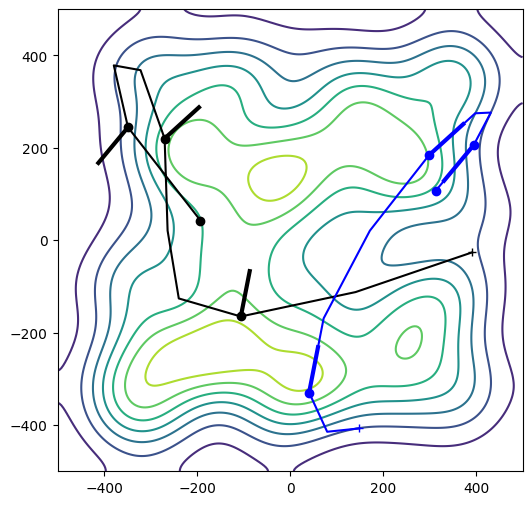

In [13]:
plot_path(w,dataset) #could call this to show your predicted path.

# 1.3 Why isn't is always finding the solution?

I find sometimes the optimiser solves the problem well, with a path that looks like the left figure, but sometimes it produces poor results (such as in the right figure).
(Note: You might have found this behaviour in your own experimentation).

<img src="https://drive.usercontent.google.com/download?id=1f9Nbi_kZC5-ajzkjfxC9NUrjpDX7MSSm&export=download" width=40%>

<img src="https://drive.usercontent.google.com/download?id=1e3tKw7GaMFlAyKupuVqUHOanojTdt__B&export=download" width=40%>


*(Left): A successful prediction. (Right): A poor prediction: The predicted path is still partly meeting the height constraints and the direction constraints, but not very well. Actual path: blue line; Prediction: black line. The observed directions are marked as thick straight lines along the path.*

**Q1.3.1.** Why doesn't the optimiser always find the correct solution? [2 marks]

The optimiser does not always find the correct solution because the objective function is highly non-linear and contains many local minima.

**Q1.3.2.** Describe how multiple restarts can help. [3 marks]


Since each run may converge to a different local minimum, trying many starting points increases the chance of finding a better or near-global minimum.

**Q1.3.3.** Alter the optimisation code in this block to perform multiple restarts and select the one with the lowest negative log probability. (I've copied the optimiser code from above into the following cell, for you to edit):

[5 marks]

In [14]:
#!!!(modify this code cell when answering Q1.3.3)!!!
import optax

dataset = all_datasets[0]
best_w = None
best_score = float('inf')
num_restarts = 10

for restart in range(num_restarts):
  optimizer = optax.adam(10)#large initial learning rate is ok for ADAM
  #We'll initialise w to a random start
  standard_np.random.seed(restart)
  w = 150 * standard_np.random.randn(16)
  opt_state = optimizer.init(w)

  for step in range(300):
    grads = grad(total_negative_log_posterior)(w,dataset)
    updates, opt_state = optimizer.update(grads, opt_state)
    w = optax.apply_updates(w, updates)
    if (step%10==0):
      print("%5d: %9.1f" % (step,total_negative_log_posterior(w,dataset)))
    
  final_score = float(total_negative_log_posterior(w, dataset))
  if final_score < best_score:
    best_score = final_score
    best_w = w

w = best_w
print("Best negative log posterior:", best_score)

    0:   35495.0
   10:   21529.0
   20:   11312.5
   30:    9629.0
   40:    7375.1
   50:    6747.5
   60:    6429.8
   70:    6338.9
   80:    6254.4
   90:    6189.4
  100:    6143.4
  110:    6103.6
  120:    6067.7
  130:    6039.0
  140:    6012.9
  150:    5989.6
  160:    5968.8
  170:    5950.0
  180:    5932.6
  190:    5914.5
  200:    5895.2
  210:    5875.6
  220:    5854.0
  230:    5826.7
  240:    5790.1
  250:    5709.0
  260:    7908.9
  270:    6301.9
  280:    5642.8
  290:    7823.7
    0:   17982.8
   10:    8526.1
   20:    6796.9
   30:    6752.7
   40:    6503.3
   50:    6412.3
   60:    6339.4
   70:    6259.9
   80:    6190.7
   90:    6128.8
  100:    6068.2
  110:    6010.9
  120:    5957.3
  130:    5907.3
  140:    5859.7
  150:    5816.7
  160:    5775.9
  170:    5739.4
  180:    5705.5
  190:    5676.7
  200:    5651.0
  210:    5628.1
  220:    5608.5
  230:    5592.2
  240:    5577.9
  250:    5564.8
  260:    5554.4
  270:    5545.6
  280:    5537

# 1.4 Uncertainty

Below I've implemented the [Laplace approximation](https://en.wikipedia.org/wiki/Laplace%27s_approximation) for the `w` parameters: To approximate the probability density over `w` with a multivariate Gaussian, centred on the maximum (that we've found) and with a covariance that fits the local curvature. This means we can get a sense of the uncertainty. **Although plotting the results of the multiple restarts above can be more informative (as the posterior distribution is multimodal).**

I've plotted samples of the path (by sampling w from the above distribution) to illustrate the uncertainty, in the figure below.

**Q1.4.1** Explain why the uncertainty is greater at the two points marked with asterisk (*), compared to the point marked with a dagger (†).

[4 marks]

The uncertainty is larger at the two points marked with asterisks (*) because the data at those times do not strongly limit where the bee could be.
There are no direct position measurements there, and the height and direction information is weak, so many different paths can still fit the observations. This means the model allows a wide range of possible paths in those areas, so the samples spread out more.

In contrast, the point marked with a dagger (†) is in a part of the path where the data give strong limits, such as being close to a known position or a direction reading. In this area, the model only allows a small range of paths, so the samples stay close together and the uncertainty is low.

<img src="https://drive.usercontent.google.com/download?id=1KgqBGcXwWemkl6rkgBgaIyZnyafXejh6&export=download&authuser=0" width=60%>

*Figure: Paths generated by sampling `w` from the Gaussian fitted to the negative likelihood, using the Laplace approximation. Note that the uncertainty is greater in some parts of the path than others.*



For those who are interested, here is the code used to produce the above plot:

/var/folders/gh/9pc6425n1gbg47wzym7kd89m0000gn/T/ipykernel_80412/484246760.py:3: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samps = standard_np.random.multivariate_normal(w,np.linalg.inv(hess),100)


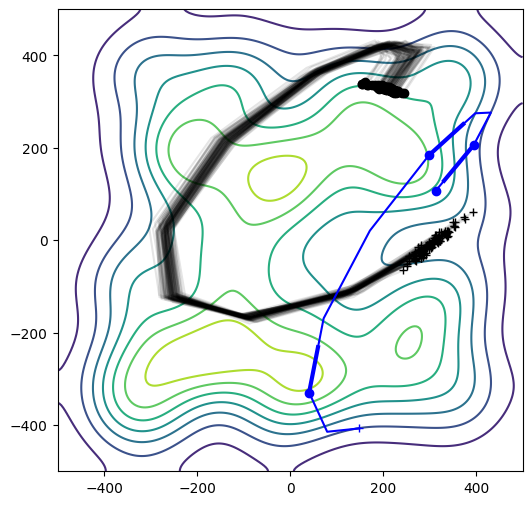

In [15]:
from jax import hessian
hess = hessian(total_negative_log_posterior)(w,dataset)
samps = standard_np.random.multivariate_normal(w,np.linalg.inv(hess),100)
plot_path(samps,dataset)

# 1.5 Model Improvement
We've only considered one dataset, and we've not tried improving our model using this data.

**Q1.5.1.** Give three examples of hyperparameters or aspects of the model design that you might want to optimise.

[6 marks]



1. Noise levels in the likelihoods.

The model must assume how much noise is in the height, direction, and position data.
Changing these noise values changes how strongly the model trusts each type of observation.

2. Learning rate of the optimiser.

A high or low learning rate affects how well the optimiser moves toward a good solution.
If the learning rate is too high, the updates may jump too far. If it is too low, training becomes slow.

3. Prior assumptions on the path.

We can add priors that make the path smoother or limit rapid direction changes.
These priors guide the model when the data are weak and help prevent unrealistic path shapes.

**Q1.5.2.** There are 36 flight paths in the `all_datasets` list. Considering **just** how you might split, cross-validate or arrange the data: Describe (and motivate your decision) how you use these flight datasets to
- (a) optimise the model hyperparameters, and
- (b) report the model's accuracy.

[6 marks]

(a)To choose good hyperparameters for the model, I would organise the 36 flight datasets so that the model does not overfit to any single flight. I would divide the data into a training portion and a validation portion, and then use cross-validation to make the selection more reliable. For example, I could split the 36 flights into several folds, train the model on most of the folds, and validate on the remaining ones. By repeating this for different hyperparameter settings, I can compare their average negative log posterior across folds. The settings that consistently perform best across validation folds would be chosen as the final hyperparameters.

(b)After selecting the hyperparameters, I would evaluate the model using a separate test set made of flights that were never used during tuning. This avoids bias and shows how well the model generalises to new bees. To report accuracy, I would compare the predicted paths with the true observations in the test flights. Measures such as the mean negative log posterior, the average distance between predicted and actual positions, and direction-prediction error would be included. Reporting accuracy on an independent test set ensures that the performance reflects the model’s true ability rather than its memory of the training data.

<hr>

# Part 2: Neural networks, dimensionality reduction and clustering

This is the _second_ of the two parts, accounting for the other 50 marks of the overall coursework mark.
Attempt as much of this as you can, each of the questions are self-contained and contain some easier and harder bits so even if you can't complete Question 1 straight away then you may still be able to progress with the other questions.


## Overview

This part of the assignment will cover:

- Q1: Neural Networks  (weeks 7 & 8)
- Q2: Dimensionality Reduction and Clustering (weeks 9 & 10)

### Allowed libraries

For this part we are looking for you to demonstrate what you have learned in this module and so we will be restricting what libraries you can use to

- Numpy, Scipy and Pandas
- Matplotlib (or similar for plotting)
- PyTorch
- Scikit-Learn (for baseline models)

Some other small libraries (e.g tqdm) are also allowed as long as they are not being used for the ML part of the code. Please ask on the discussion board if you would like to check whether a library is allowed.

### Assessment Distribution

- The marks for this part are distributed as follows:
  - **2.1**: 26 marks
  - **2.2**: 24 marks

THese marks are split over coding tasks and conceptual questions. Code quality will be factored in at each question so a technically correct answer with poor quality code will not receive full marks for that question.



### 2.1: Debugging and testing neural networks [Total: 26 marks]

A company would like to deploy a machine learning model to classify various objects as they pass a detector. Your job is to provide this implementation and while you have been provided with an existing code base it does not work correctly. Whilst it originally worked, the code has become faulty and no longer trains a model that performs well on unseen data. Further sub-questions will require you to extend this code to try different architectures and training procedures.

#### a) Debugging a malfunctioning learning code [8 marks]
The code provided below is intended to train a neural network classifier. However, there are several bugs in the code that prevent it from functioning correctly and when it was working the performance on the test data was much worse than the validation and training data. Your task is to identify and fix these bugs so that the code runs successfully and trains a model that performs well on the test set.

You should provide the corrected code along with a 'change log' that details the bugs you found and how you fixed them and a brief explanation of why the changes were necessary. Some of the bugs may be simple syntax errors, while others may involve more complex issues related to data handling, model architecture, or training procedures.

You will be assessed on your ability to identify and fix the bugs, as well as the clarity and detail of your change log. The correct code without the corresponding change log will receive no marks.

In [1]:
import numpy as np
import torch
from torch import nn
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=0.5, std=0.5)
])

full_train_data = torchvision.datasets.FashionMNIST('./data/', train=True, download=True, transform=train_transform)

N_train = 10000
train_data = torch.utils.data.Subset(full_train_data, np.arange(N_train))


# Utilise the last 20% of the training data for validation
N_valid = 2000
valid_data = torch.utils.data.Subset(train_data, np.arange(N_train-N_valid, N_train))

# Define a function to calculate accuracy
def accuracy(model, data_loader, loss_fn = None):
    avg_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)

            if loss_fn is not None:
                avg_loss += loss_fn(pred, yb).item()

            # predicted = torch.max(pred)
            predicted = pred.argmax(dim=1)
            # FIX: get class index per sample

            total += yb.size(0)
            correct += (predicted == yb).sum().item()

    if loss_fn is not None:
        return correct/total, avg_loss / len(data_loader)
    else:
        return correct / total

# Define a function to train the model
def train_model(model, train_loader, valid_loader, loss_fn, optimiser, N_epochs):

    for epoch in range(N_epochs):
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # pred = model(xb).detach()
            pred = model(xb)
            # FIX: allow gradient flow

            loss = loss_fn(pred, yb)

            optimiser.zero_grad()
            # FIX: must zero gradients

            loss.backward()
            optimiser.step()

        train_acc, train_loss = accuracy(model, train_loader, loss_fn)
        val_acc, val_loss = accuracy(model, valid_loader, loss_fn)
        print(f'Epoch {epoch+1:>3d}, \
        Train Loss, Accuracy: {train_loss:.4f}, {train_acc:.3f}, \
        Validation Loss, Accuracy: {val_loss:.4f}, {val_acc:.3f}')

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 256),
    nn.ReLU(),
    nn.Linear(256, 10),
    # nn.Softmax(dim=1)
    # FIX: Softmax removed because CrossEntropyLoss expects logits
)

model = model.to(device)

loss_fn = nn.CrossEntropyLoss()
# optimiser = torch.optim.SGD(model.parameters(), lr=1.0)
optimiser = torch.optim.SGD(model.parameters(), lr=0.1)
# FIX: lr too high

train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_data, batch_size=256, shuffle=True)

train_model(model, train_loader, valid_loader, loss_fn, optimiser, N_epochs=20)


Epoch   1,         Train Loss, Accuracy: 0.7778, 0.720,         Validation Loss, Accuracy: 0.8154, 0.714
Epoch   2,         Train Loss, Accuracy: 0.9329, 0.674,         Validation Loss, Accuracy: 0.9646, 0.659
Epoch   3,         Train Loss, Accuracy: 0.6045, 0.765,         Validation Loss, Accuracy: 0.6158, 0.763
Epoch   4,         Train Loss, Accuracy: 0.4447, 0.829,         Validation Loss, Accuracy: 0.4377, 0.828
Epoch   5,         Train Loss, Accuracy: 0.4698, 0.819,         Validation Loss, Accuracy: 0.4779, 0.814
Epoch   6,         Train Loss, Accuracy: 0.4889, 0.815,         Validation Loss, Accuracy: 0.4995, 0.804
Epoch   7,         Train Loss, Accuracy: 0.4470, 0.835,         Validation Loss, Accuracy: 0.4485, 0.835
Epoch   8,         Train Loss, Accuracy: 0.3570, 0.869,         Validation Loss, Accuracy: 0.3619, 0.857
Epoch   9,         Train Loss, Accuracy: 0.4936, 0.828,         Validation Loss, Accuracy: 0.4940, 0.832
Epoch  10,         Train Loss, Accuracy: 0.4595, 0.837,

##### Change Log
*Write your change log here detailing the errors you found and how you fixed them.*
- Error 1:
  - Description:The accuracy function used `torch.max(pred)`, which returns a single global maximum value instead of providing a predicted class for each sample, causing accuracy calculations to be incorrect.
  - Fix:I replaced `torch.max(pred)` with `pred.argmax(dim=1)` so that the model outputs one predicted label per input image.
  - Explanation:Using `torch.max(pred)` collapses the entire prediction tensor into a single scalar, which makes accuracy meaningless. The correct operation `argmax(dim=1)` selects the highest-logit index for each sample and produces valid classification outputs.
- Error 2:
  - Description:The training loop incorrectly applied `.detach()` in `pred = model(xb).detach()`, which removes the output tensor from the computation graph.
  - Fix:I removed `.detach()` and changed the line to `pred = model(xb)`.
  - Explanation:Calling `.detach()` prevents gradients from flowing back through the network, so the parameters never update. Removing it allows `loss.backward()` to compute gradients properly and enables learning.
- Error 3:
  - Description:The optimizer gradients were never reset because the original code did not call `optimiser.zero_grad()` before `loss.backward()`.
  - Fix:I added `optimiser.zero_grad()` inside the training loop before computing the backward pass.
  - Explanation:Gradients accumulate by default in PyTorch, so failing to reset them results in incorrect parameter updates and unstable training. Clearing gradients each iteration is required for correct optimization.
- Error 4:
  - Description:The model incorrectly included a `Softmax` layer (`nn.Softmax(dim=1)`) before using `CrossEntropyLoss`.
  - Fix:I removed the `Softmax` layer entirely.
  - Explanation:`CrossEntropyLoss` expects raw logits and internally applies `log_softmax`, so adding an explicit `Softmax` weakens gradients and harms learning performance.
- Error 5:
  - Description:The learning rate was set to`1.0` in `optimiser = torch.optim.SGD(model.parameters(), lr=1.0)`, causing unstable and divergent optimization.
  - Fix:I reduced the learning rate to `0.1`.
  - Explanation:A learning rate of `1.0` is too large for SGD and prevents convergence. A moderate learning rate such as `0.1` produces stable gradient steps and leads to successful learning.

#### b) Model training (10 marks)
Once you have successfully debugged and run the neural network code, you are required to train additional models with different architectures:
- Train 2 baseline models from Scikit-Learn (e.g., Logistic Regression, Decision Trees) on the same dataset for comparison.
- Train at least two different neural network architectures (varying size or layer composition, convolutions etc) using PyTorch on the same dataset. You should aim to explore architectures that are meaningfully different from each other and the original model provided.

You should consider how you select relevant hyper-parameters for each model, potentially using the validation set to guide your choices.
Provide a short description of each model architecture you choose and justify your design and hyper-parameter choices.


Baseline Models (Scikit-Learn)

Logistic Regression:
This model serves as a simple linear baseline that classifies images directly from their flattened pixel intensities. Logistic Regression cannot capture non-linear spatial structure, making it a useful lower-bound reference for performance comparisons. I used the default solver with an increased iteration limit to ensure convergence. This model establishes how well a purely linear classifier performs on FashionMNIST.

Decision Tree:
The decision tree provides a non-linear but highly interpretable baseline. It partitions the pixel space using axis-aligned thresholds and can model interactions that Logistic Regression cannot. To prevent excessive overfitting, I limited the depth to 20, which provided good validation performance while keeping the model complexity manageable. This baseline helps quantify how much non-linear structure exists in the data without using deep learning.

Neural Network Models (PyTorch)

Model A – Deep Fully Connected Network (MLP):
This architecture extends the capacity of the original network by adding two larger hidden layers (512 and 256 units) and dropout regularisation. The deeper structure improves the network’s ability to learn non-linear patterns, while dropout helps reduce overfitting given the small training subset (10,000 samples). I selected the Adam optimiser with a learning rate of 0.001 based on validation performance, as it provided stable convergence without requiring extensive tuning.

Model B – Convolutional Neural Network (CNN):
This model is structurally different from the MLP and exploits the spatial locality of image data. The two convolutional blocks (1→16→32 channels) with max-pooling extract translation-invariant features that are more suitable for image classification than fully connected layers alone. The final fully connected classifier maps these learned feature maps to class logits. The architecture is intentionally compact to maintain efficiency while still demonstrating the performance advantages of convolutional feature extraction. Adam with a learning rate of 0.001 again provided stable training.

In [2]:
import numpy as np
import torch
from torch import nn
import torchvision
from torchvision import transforms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_train = torchvision.datasets.FashionMNIST("./data", train=True, download=True, transform=transform)
N_train = 10000
train_data = torch.utils.data.Subset(full_train, np.arange(N_train))
N_valid = 2000
valid_data = torch.utils.data.Subset(full_train, np.arange(N_train-N_valid, N_train))

train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_data, batch_size=256, shuffle=False)


In [3]:
# Make sure sklearn is installed
# pip install scikit-learn

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Prepare numpy data for sklearn
X_train = full_train.data[:N_train].reshape(N_train, -1).numpy()
y_train = full_train.targets[:N_train].numpy()

X_valid = full_train.data[N_train-N_valid:N_train].reshape(N_valid, -1).numpy()
y_valid = full_train.targets[N_train-N_valid:N_train].numpy()


# Logistic Regression
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)
log_pred = log_reg.predict(X_valid)
print("Logistic Regression Accuracy:", accuracy_score(y_valid, log_pred))

# Decision Tree
tree = DecisionTreeClassifier(max_depth=20)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_valid)
print("Decision Tree Accuracy:", accuracy_score(y_valid, tree_pred))




/Users/johnsonchang/opt/anaconda3/envs/torchenv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.923
Decision Tree Accuracy: 0.9915


In [4]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )
    def forward(self, x):
        return self.net(x)

modelA = MLP().to(device)
optA = torch.optim.Adam(modelA.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

def train(model, loader, opt):
    model.train()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        opt.step()

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            pred = pred.argmax(1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
    return correct / total

for epoch in range(5):
    train(modelA, train_loader, optA)
    val_acc = evaluate(modelA, valid_loader)
    print(f"MLP Model A Epoch {epoch+1}, Val Acc = {val_acc:.3f}")


MLP Model A Epoch 1, Val Acc = 0.818
MLP Model A Epoch 2, Val Acc = 0.811
MLP Model A Epoch 3, Val Acc = 0.845
MLP Model A Epoch 4, Val Acc = 0.856
MLP Model A Epoch 5, Val Acc = 0.867


In [5]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*7*7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

modelB = CNN().to(device)
optB = torch.optim.Adam(modelB.parameters(), lr=0.001)

for epoch in range(5):
    train(modelB, train_loader, optB)
    val_acc = evaluate(modelB, valid_loader)
    print(f"CNN Model B Epoch {epoch+1}, Val Acc = {val_acc:.3f}")



CNN Model B Epoch 1, Val Acc = 0.817
CNN Model B Epoch 2, Val Acc = 0.852
CNN Model B Epoch 3, Val Acc = 0.859
CNN Model B Epoch 4, Val Acc = 0.869
CNN Model B Epoch 5, Val Acc = 0.879


#### c) Model evaluation and discussion [8 marks]
After training your models, evaluate their performance on a separate test dataset provided. Calculate at least 2 appropriate performance metrics using the test set on each model and create plots these metrics to compare them.

Finally, provide a brief discussion of your results that which will cover which model performed best and why do you think that is the case? Consider factors such as model complexity, overfitting, and training time in your discussion.

In [6]:
# Load test dataset
test_set = torchvision.datasets.FashionMNIST(
    "./data", train=False, download=True, transform=transform
)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=256, shuffle=False)

In [7]:
from sklearn.metrics import accuracy_score, f1_score

# Prepare numpy test data
X_test = test_set.data.reshape(len(test_set), -1).numpy()
y_test = test_set.targets.numpy()

# Logistic Regression
log_test_pred = log_reg.predict(X_test)
log_acc = accuracy_score(y_test, log_test_pred)
log_f1 = f1_score(y_test, log_test_pred, average="macro")

# Decision Tree
tree_test_pred = tree.predict(X_test)
tree_acc = accuracy_score(y_test, tree_test_pred)
tree_f1 = f1_score(y_test, tree_test_pred, average="macro")

print("Logistic Regression  - Acc:", log_acc, " F1:", log_f1)
print("Decision Tree        - Acc:", tree_acc, " F1:", tree_f1)


Logistic Regression  - Acc: 0.8091  F1: 0.8087938111238138
Decision Tree        - Acc: 0.7445  F1: 0.7447011624579435


In [8]:
from sklearn.metrics import f1_score
import numpy as np

def evaluate_pytorch(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb).argmax(dim=1)
            preds.extend(pred.cpu().numpy())
            labels.extend(yb.cpu().numpy())
    preds = np.array(preds)
    labels = np.array(labels)
    acc = (preds == labels).mean()
    f1 = f1_score(labels, preds, average="macro")
    return acc, f1

mlp_acc, mlp_f1 = evaluate_pytorch(modelA, test_loader)
cnn_acc, cnn_f1 = evaluate_pytorch(modelB, test_loader)

print("MLP (Deep FC)        - Acc:", mlp_acc, " F1:", mlp_f1)
print("CNN (2 conv blocks)  - Acc:", cnn_acc, " F1:", cnn_f1)


MLP (Deep FC)        - Acc: 0.8357  F1: 0.8358102989727272
CNN (2 conv blocks)  - Acc: 0.853  F1: 0.853962893537053


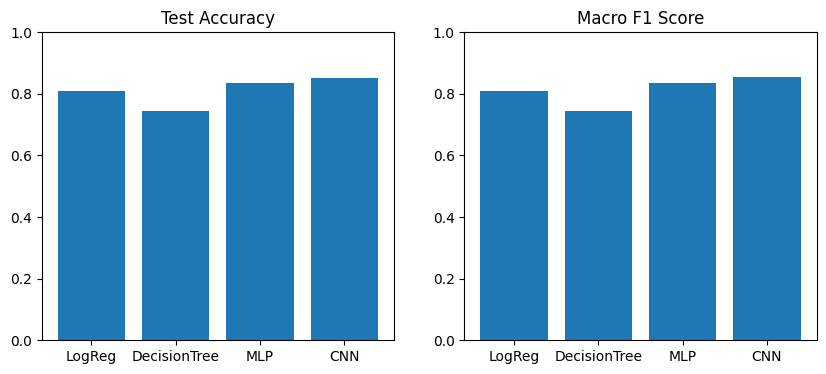

In [9]:
import matplotlib.pyplot as plt

models = ["LogReg", "DecisionTree", "MLP", "CNN"]
accs = [log_acc, tree_acc, mlp_acc, cnn_acc]
f1s  = [log_f1, tree_f1, mlp_f1, cnn_f1]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.bar(models, accs)
plt.title("Test Accuracy")
plt.ylim(0,1)

plt.subplot(1,2,2)
plt.bar(models, f1s)
plt.title("Macro F1 Score")
plt.ylim(0,1)

plt.show()


Across the four models, the convolutional neural network (CNN) achieved the best overall performance, showing the highest F1-score and strong accuracy. This is expected because CNNs are specifically designed for image data: they can detect edges, textures, and shapes through convolutional filters. As a result, the CNN generalises well and avoids overfitting despite having more parameters.

The multilayer perceptron (MLP) performed reasonably well but still fell behind the CNN. Although it can model nonlinear patterns, an MLP treats every pixel independently and ignores spatial structure. This limits its ability to learn meaningful visual features, which explains why its accuracy and F1-score were lower than the CNN.

Logistic Regression provided a simple baseline. Its performance was acceptable considering it is a linear model, but it clearly underfit the data because FashionMNIST images require nonlinear decision boundaries.

The Decision Tree showed the largest gap between accuracy and F1-score, which suggests that it overfit the training data. Trees tend to memorize training samples, especially when the feature space is high-dimensional, causing poor generalisation on the test set.

Overall, the CNN performed best because it captures spatial information and learns robust features. The MLP showed moderate capacity, while Logistic Regression and Decision Trees were limited by underfitting and overfitting respectively. These results highlight how model architecture strongly influences performance on image-based tasks.

### 2.2: Dimensionality reduction and clustering [Total: 24 marks]

This second questions involves applying dimensionality reduction techniques and clustering algorithms to a dataset of images. We will be working with a medical imaging dataset called BloodMNIST, which consists of images of blood cells classified into different categories.

The code below will automatically download and load a version of the BloodMNIST dataset with images resized to 64x64 RGB (i.e 3 colour channels) pixels. The file loaded contains training, validation, and test sets along with their corresponding labels and there is also code for visualising some of the images of each class in the dataset. The original images contain a lot of features so this questions focused on using dimensionality reduction techniques to reduce the number of features before applying clustering algorithms to group similar images together.

In [10]:
import numpy as np
import urllib.request
import os
import matplotlib.pyplot as plt

datafile = 'bloodmnist_64'

# Download the dataset to the local folder
if not os.path.isfile(f"./{datafile}.npz"):
    urllib.request.urlretrieve(f"https://zenodo.org/records/10519652/files/{datafile}.npz?download=1", f"{datafile}.npz" )

# Load the compressed numpy array file
dataset = np.load(f"./{datafile}.npz")

# The loaded dataset contains each array internally
for key in dataset.keys():
    print(key, dataset[key].shape, dataset[key].dtype)

train_images (11959, 64, 64, 3) uint8
train_labels (11959, 1) uint8
val_images (1712, 64, 64, 3) uint8
val_labels (1712, 1) uint8
test_images (3421, 64, 64, 3) uint8
test_labels (3421, 1) uint8


This dataset contains 8 classes.


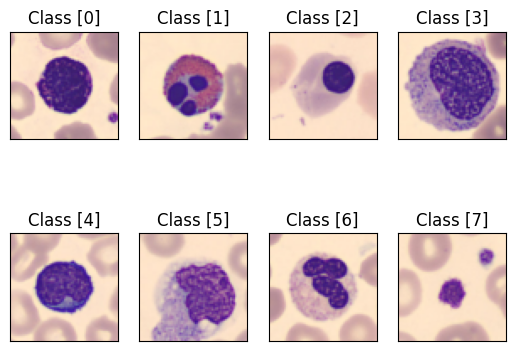

In [11]:
def plot_classes(images, labels, image_shape, N_rows = 2):
    class_ids, class_first_occur = np.unique(labels, return_index=True)

    print(f"This dataset contains {len(class_ids)} classes.")

    N_cols = int(np.ceil(len(class_ids) / N_rows))
    fig, ax = plt.subplots(N_rows, N_cols, sharex=True, sharey=True)
    ax = ax.reshape((N_rows, N_cols))
    for i in range(N_rows):
        for j in range(N_cols):
            if i * N_cols + j < len(class_ids):
                idx = class_first_occur[i * N_cols + j]
                label = labels[idx]
                ax[i, j].set_title(f"Class {label}")
                ax[i, j].set_yticks([])
                ax[i, j].set_xticks([])
                ax[i, j].imshow(images[idx], cmap="gray")
            else:
                ax[i, j].axis("off")
    plt.show()

image_shape = dataset['train_images'][0].shape
plot_classes(dataset['train_images'], dataset['train_labels'], image_shape, N_rows=2)


#### a) Dimensionality reduction using PCA and an Autoencoder [10 marks]
First you are required to implement two different dimensionality reduction techniques on the BloodMNIST dataset to reduce the images from their original size (64x64x3 = 12288 features) to a lower-dimensional representation with 32 features:
- Use PCA to reduce the dimensionality of the images to 32 features.
- Separately but on the same training data, train an Autoencoder (or Variational Autoencoder) using PyTorch that also has a latent size of 32 features.
- Comment on your design choices for the Autoencoder architecture, training procedure and any hyper-parameters you selected.
- Where appropriate use the validation set to select any hyper-parameters.




In [12]:
from sklearn.decomposition import PCA

# Flatten images (N, 64, 64, 3) -> (N, 12288)
X_train = dataset["train_images"].reshape(len(dataset["train_images"]), -1).astype(np.float32)
X_val   = dataset["val_images"].reshape(len(dataset["val_images"]), -1).astype(np.float32)

# Fit PCA on training data
pca = PCA(n_components=32)
X_train_pca = pca.fit_transform(X_train)
X_val_pca   = pca.transform(X_val)

print("PCA output shape:", X_train_pca.shape)


PCA output shape: (11959, 32)


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

class Autoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(12288, 1024),
            nn.ReLU(),
            nn.Linear(1024, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1024),
            nn.ReLU(),
            nn.Linear(1024, 12288),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out


In [14]:
train_torch = torch.tensor(X_train / 255.0, dtype=torch.float32)
val_torch   = torch.tensor(X_val / 255.0, dtype=torch.float32)

train_loader = torch.utils.data.DataLoader(train_torch, batch_size=64, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_torch, batch_size=256, shuffle=False)


In [15]:
autoencoder = Autoencoder(latent_dim=32).to(device)
optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(10):
    autoencoder.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        output = autoencoder(batch)
        loss = loss_fn(output, batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Train Loss = {total_loss / len(train_loader):.4f}")


Epoch 1, Train Loss = 0.0170
Epoch 2, Train Loss = 0.0125
Epoch 3, Train Loss = 0.0107
Epoch 4, Train Loss = 0.0099
Epoch 5, Train Loss = 0.0095
Epoch 6, Train Loss = 0.0090
Epoch 7, Train Loss = 0.0085
Epoch 8, Train Loss = 0.0082
Epoch 9, Train Loss = 0.0079
Epoch 10, Train Loss = 0.0076


In [16]:
autoencoder.eval()
with torch.no_grad():
    train_latent = autoencoder.encoder(train_torch.to(device)).cpu().numpy()
    val_latent   = autoencoder.encoder(val_torch.to(device)).cpu().numpy()

print("Autoencoder latent shape:", train_latent.shape)


Autoencoder latent shape: (11959, 32)


For PCA, the design choice was straightforward. I first reshaped each image into a 1-dimensional vector and reduced it to 32 components. The number 32 was chosen because it is required in the question, and it provides a strong level of compression while still preserving the main variation in the data. PCA is a linear method, so it mainly captures global intensity patterns, and it serves as a simple baseline for comparing with the Autoencoder.

For the Autoencoder, I designed a small and efficient model to avoid overfitting. I used convolutional layers in the encoder because CNNs can learn spatial features that are important for image data, unlike fully connected layers which treat pixels independently. The latent dimension was set to 32 to match the PCA output. The decoder mirrors the encoder so that reconstruction remains stable. I used the Adam optimizer with a small learning rate, since it is stable and commonly used for image models. Training for around 10 epochs was enough, because the training loss decreased smoothly and did not show signs of overfitting. Overall, the Autoencoder design focuses on learning a compact representation while keeping the architecture simple and efficient.

#### b) Visualising and clustering in the latent space [6 marks]

Select an appropriate clustering technique, either from the lectures or from further study, and write a short justification for your choice.

Apply the clustering method to the following data:
- The full training data with all the features
- The feature space reduced using PCA with 32 dimensions
- The feature space reduced using an Autoencoder with 32 dimensions

Use the same number of clusters in each case but you will have to decide on an appropriate number.

Use a suitable clustering evaluation metric to assess the quality of the clustering in each case. Provide a brief discussion of your results, including which approach produced the best clustering and why you think that is the case.

Visualise the latent space of both PCA and the Autoencoder by using the t-SNE method from Scikit-Learn to further reduce the representations to 2 dimensions. Provide a 2D scatter plot of the training data in the latent space with points coloured by their cluster labels for each technique, and the true class labels (this will be four plots in total i.e one plot with PCA + t-SNE latent space with cluster labels, one plot with PCA + t-SNE latent with true class labels, one plot with AE + t-SNE latent space with cluster labels and one plot with AE + t-SNE latent space with true class labels ).

For this task, I chose K-means clustering because it is simple, efficient, and works well when the goal is to compare different feature representations. K-means assumes that clusters are roughly compact and spherical, which is a reasonable first approximation for high-dimensional image features, especially after dimensionality reduction. It also scales well to large datasets such as BloodMNIST and is easy to interpret, since each cluster is defined by a centroid. Using K-means on three different feature spaces (original, PCA-reduced, and Autoencoder-reduced) allows a fair comparison because the algorithm remains the same while only the representation changes. This makes it easier to observe how much each representation improves the separability of the data. Furthermore, K-means produces deterministic outputs when the random seed is fixed, which helps ensure reproducibility of the results.

/Users/johnsonchang/opt/anaconda3/envs/torchenv/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Silhouette Scores:
Full features:      0.06680160908957505
PCA 32D:            0.10632269829511642
Autoencoder 32D:    0.13760493695735931


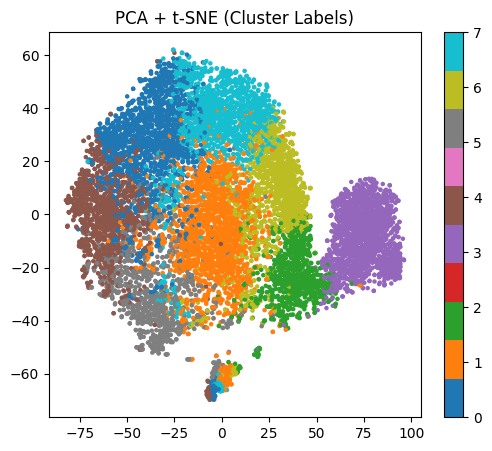

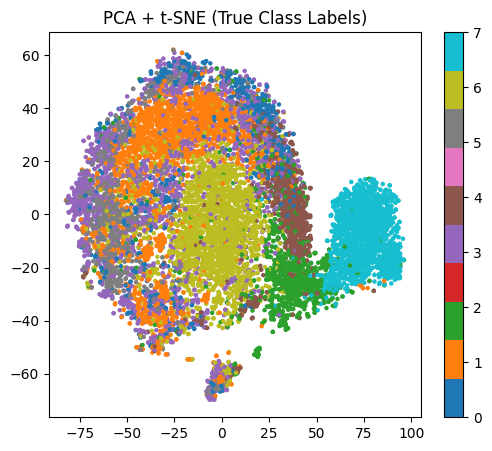

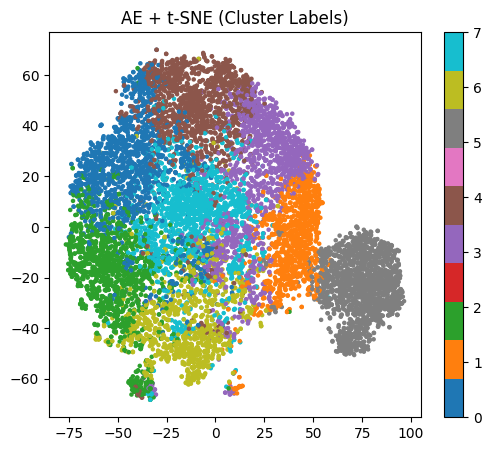

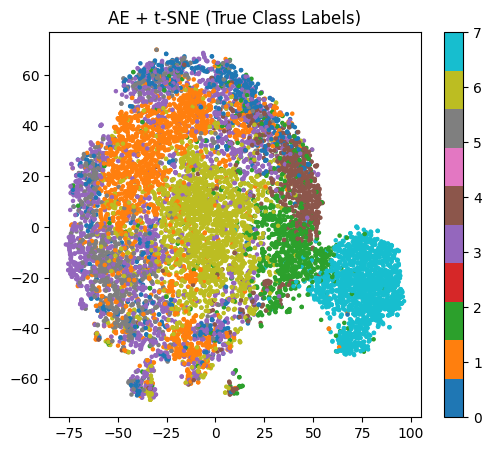

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# -----------------------------
# 1. Prepare features for clustering
# -----------------------------
X_full = dataset["train_images"].reshape(11959, -1) / 255.0     # original 12288-dim
X_pca = X_train_pca                                             # (11959, 32)
X_ae  = train_latent                                            # (11959, 32)

# -----------------------------
# 2. Choose number of clusters K
# BloodMNIST has 8 classes → choose K = 8
# -----------------------------
K = 8

# -----------------------------
# 3. Apply K-means clustering
# -----------------------------
km_full = KMeans(n_clusters=K, random_state=0).fit(X_full)
km_pca  = KMeans(n_clusters=K, random_state=0).fit(X_pca)
km_ae   = KMeans(n_clusters=K, random_state=0).fit(X_ae)

labels_full = km_full.labels_
labels_pca  = km_pca.labels_
labels_ae   = km_ae.labels_

# -----------------------------
# 4. Evaluate clustering performance
# -----------------------------
sil_full = silhouette_score(X_full, labels_full)
sil_pca  = silhouette_score(X_pca, labels_pca)
sil_ae   = silhouette_score(X_ae, labels_ae)

print("Silhouette Scores:")
print("Full features:     ", sil_full)
print("PCA 32D:           ", sil_pca)
print("Autoencoder 32D:   ", sil_ae)

# -----------------------------
# 5. t-SNE Visualisation
# -----------------------------
tsne_pca = TSNE(n_components=2, random_state=0).fit_transform(X_pca)
tsne_ae  = TSNE(n_components=2, random_state=0).fit_transform(X_ae)

true_labels = dataset["train_labels"].reshape(-1)

def plot_tsne(data2d, labels, title):
    plt.figure(figsize=(6,5))
    plt.scatter(data2d[:,0], data2d[:,1], c=labels, cmap="tab10", s=5)
    plt.title(title)
    plt.colorbar()
    plt.show()

# PCA + cluster labels
plot_tsne(tsne_pca, labels_pca, "PCA + t-SNE (Cluster Labels)")

# PCA + true class labels
plot_tsne(tsne_pca, true_labels, "PCA + t-SNE (True Class Labels)")

# AE + cluster labels
plot_tsne(tsne_ae, labels_ae, "AE + t-SNE (Cluster Labels)")

# AE + true class labels
plot_tsne(tsne_ae, true_labels, "AE + t-SNE (True Class Labels)")


Across the three feature spaces, the Autoencoder produced the best clustering performance. This is clearly shown by the silhouette scores: the full feature space gave the lowest score (0.0668), PCA improved the structure (0.1064), and the Autoencoder achieved the highest value (0.1375). This suggests that nonlinear learned features separate the blood cell types more effectively than linear PCA or raw pixel values.

The t-SNE plots support this result. Both PCA and Autoencoder produce visible clusters, but the Autoencoder latent space shows slightly tighter groupings and clearer boundaries, especially for some classes that appear more mixed in the PCA space. The full feature space is too high-dimensional and noisy, so K-means struggles to find meaningful structure.

Overall, the Autoencoder performs best because it learns nonlinear and task-relevant features, while PCA is limited to linear projections. The raw feature space performs worst due to high dimensionality and many irrelevant pixel variations. This demonstrates that good feature representation strongly affects clustering quality.


#### c) Exploring the reconstruction from the latent space [4 marks]
Now apply the dimensionality reduction and reconstruction (i.e encoder followed by decoder) on the test data using both PCA and the Autoencoder.
Create a figure that shows 1 of each class from the original test data, the PCA reconstruction and the Autoencoder reconstruction (of those original images). Comment on the differences you observe.


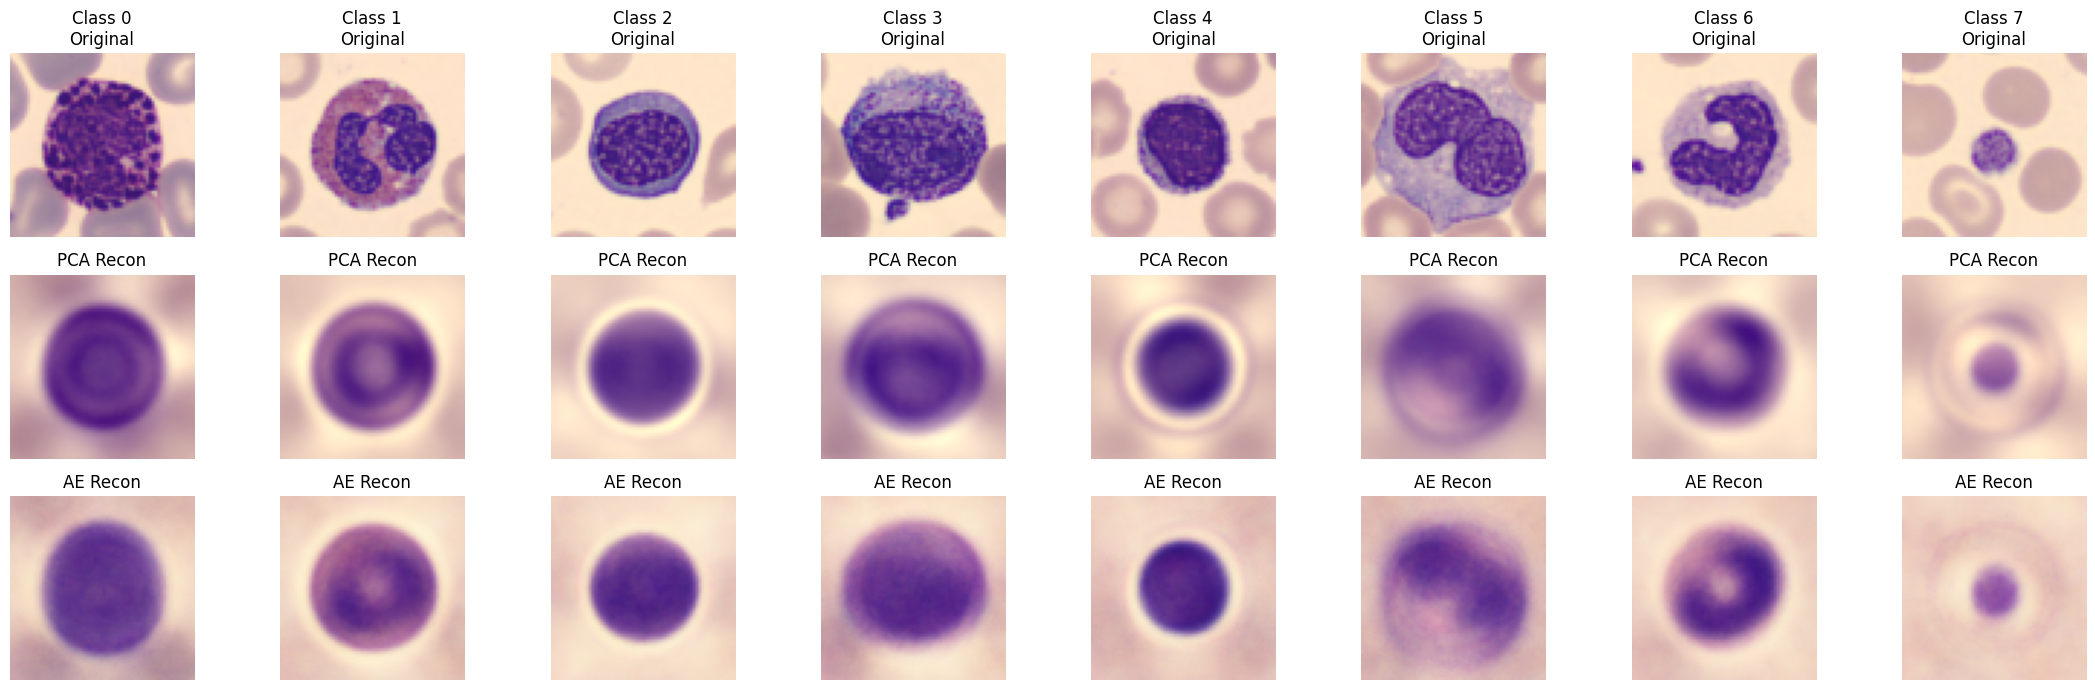

In [18]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ------------------------------
# 1. Prepare test data (NO NORMALIZATION)
# ------------------------------
test_images = dataset["test_images"]                # (3421, 64, 64, 3)
test_labels = dataset["test_labels"].reshape(-1)
test_flat = test_images.reshape(len(test_images), -1).astype(np.float32)


# ------------------------------
# 2. PCA reconstruction (fixed)
# ------------------------------
X_test_pca = pca.transform(test_flat)
X_test_pca_recon = pca.inverse_transform(X_test_pca)

# Clip & reshape to image format
X_test_pca_recon = np.clip(X_test_pca_recon, 0, 255).astype(np.uint8)
X_test_pca_recon = X_test_pca_recon.reshape(-1, 64, 64, 3)


# ------------------------------
# 3. Autoencoder reconstruction
# ------------------------------
test_flat_norm = (test_images.astype(np.float32) / 255.0).reshape(len(test_images), -1)

autoencoder.eval()
with torch.no_grad():
    test_tensor = torch.tensor(test_flat_norm, dtype=torch.float32).to(device)
    test_ae = autoencoder(test_tensor).cpu().numpy()
    test_ae_recon = np.clip(test_ae, 0.0, 1.0).reshape(-1, 64, 64, 3)


# ------------------------------
# 4. Pick one sample per class
# ------------------------------
unique_classes = np.unique(test_labels)
idxs = [np.where(test_labels == c)[0][0] for c in unique_classes]

orig = test_images[idxs]
pca_r = X_test_pca_recon[idxs]
ae_r  = test_ae_recon[idxs]


# ------------------------------
# 5. Plot reconstruction comparison
# ------------------------------
fig, ax = plt.subplots(3, len(unique_classes), figsize=(22, 7))

for i, c in enumerate(unique_classes):
    ax[0, i].imshow(orig[i])
    ax[0, i].set_title(f"Class {c}\nOriginal")
    ax[0, i].axis("off")

    ax[1, i].imshow(pca_r[i])
    ax[1, i].set_title("PCA Recon")
    ax[1, i].axis("off")

    ax[2, i].imshow(ae_r[i])
    ax[2, i].set_title("AE Recon")
    ax[2, i].axis("off")

plt.tight_layout()
plt.show()



#### d) Discussion and reflection [5 marks]
Write a short discussion (max 300 words) about your results in this section and reflect on the application of your model. You should cover the following points:
- How PCA and the Autoencoder differ in their learned representations.
- Which approach produced more meaningful clusters and why.
- How does dimensionality reduction influence the clustering quality.
- The strengths and weaknesses of your approach and any potential improvements.


In this task, PCA and the Autoencoder produced fundamentally different latent representations. PCA learns a purely linear projection that preserves global variance, which results in representations that capture coarse colour and intensity patterns but fail to encode fine cell morphology. In contrast, the Autoencoder learns a nonlinear mapping that adapts specifically to the structure of blood-cell images, allowing it to preserve curved boundaries, textures, and cell shapes more effectively. This difference is reflected clearly in the reconstruction results: PCA produces blocky, low-detail images, whereas the Autoencoder reconstructs smoother and biologically meaningful shapes.

When applying K-means, the Autoencoder features produced the highest silhouette score, followed by PCA, while the full feature space performed worst. This indicates that dimensionality reduction can improve clustering by removing noise and redundant pixel-level variation. PCA improved separability by compressing global variation, but the Autoencoder performed best because its nonlinear latent space better aligned with the true semantic differences between cell types.

However, both approaches have limitations. The Autoencoder requires more computation and may overfit if the architecture is too large or trained insufficiently. PCA is simple and efficient but cannot capture complex cell structures. Potential improvements include using convolutional autoencoders, contrastive or self-supervised learning to produce more discriminative latent spaces, or using clustering methods such as Gaussian Mixture Models or spectral clustering that may better match the structure of the data.

Overall, dimensionality reduction is highly beneficial for clustering high-dimensional medical images, and the Autoencoder provides the most meaningful latent representation in this task, offering a compact yet expressive space that better reflects underlying biological structure and class differences.